DCA-like Model (Leakage Fixed)
Train RMSE: 217.96
Test RMSE: 71.2
Test MAE: 55.63
Test R2: 0.854


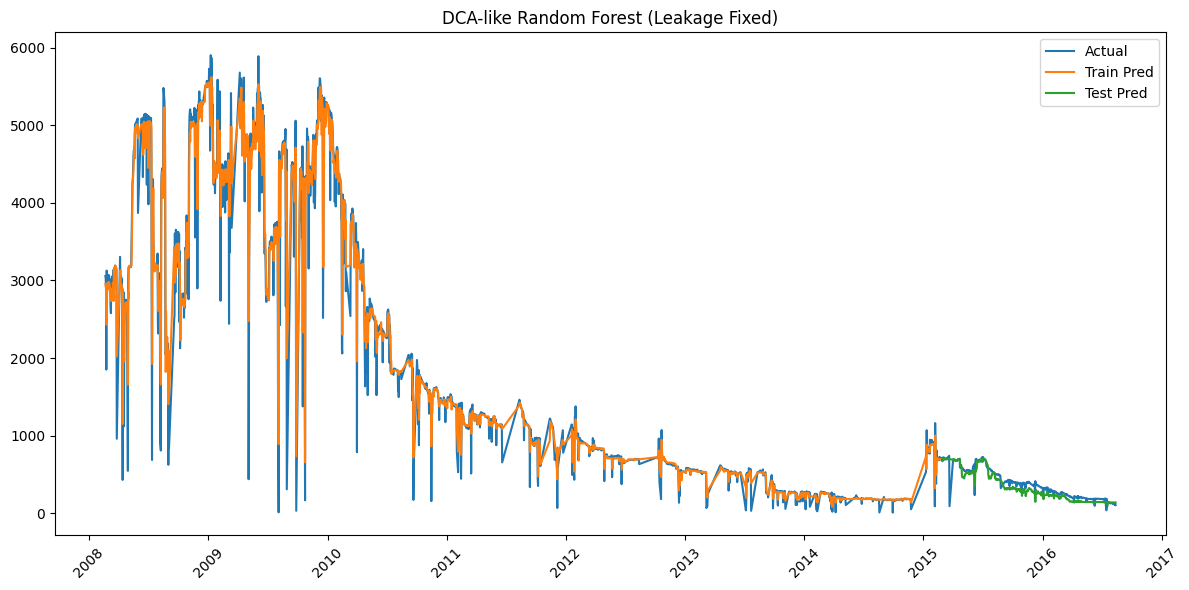


Feature Importance:
             feature  importance
1         log_q_lag1    0.639923
5    roll_mean_7_lag    0.253353
0                  t    0.091418
2  decline_rate_lag1    0.007690
4      curvature_lag    0.004246
3        slope_7_lag    0.003370


In [ ]:
# Fix leakage and rerun DCA-like model with lagged features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 

# Load
df = pd.read_csv('/home/rian/python_project/myvenv/dca_ml/data/selected_data.csv')
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])
df = df.sort_values('DATEPRD')

# Select well
well = df['WELL_BORE_CODE'].mode()[0]
df = df[df['WELL_BORE_CODE'] == well].copy()

# Aggregate by date
df = df.groupby('DATEPRD', as_index=False)['BORE_OIL_VOL'].sum()
df = df.sort_values('DATEPRD').reset_index(drop=True)

# Time index
df['t'] = (df['DATEPRD'] - df['DATEPRD'].min()).dt.days

# Replace zeros to avoid log/ratio issues
df['q'] = df['BORE_OIL_VOL'].replace(0, np.nan)

# Proper lagged (no leakage) features
df['log_q_lag1'] = np.log(df['q'].shift(1))
df['decline_rate_lag1'] = -(df['q'].shift(1) - df['q'].shift(2)) / df['q'].shift(2)
df['slope_7_lag'] = (df['q'].shift(1) - df['q'].shift(8)) / 7.0
df['curvature_lag'] = df['q'].shift(1) - 2*df['q'].shift(2) + df['q'].shift(3)
df['roll_mean_7_lag'] = df['q'].shift(1).rolling(7).mean()

features = [
    't',
    'log_q_lag1',
    'decline_rate_lag1',
    'slope_7_lag',
    'curvature_lag',
    'roll_mean_7_lag'
]

df_model = df.replace([np.inf, -np.inf], np.nan).dropna(subset=features + ['q']).copy()

X = df_model[features]
y = df_model['q']
dates = df_model['DATEPRD']

# Split
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Train
rf = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("DCA-like Model (Leakage Fixed)")
print("Train RMSE:", round(rmse_train,2))
print("Test RMSE:", round(rmse_test,2))
print("Test MAE:", round(mae_test,2))
print("Test R2:", round(r2_test,3))

# Plot
plt.figure(figsize=(12,6))
plt.plot(dates, y, label='Actual')
plt.plot(dates[:split], y_pred_train, label='Train Pred')
plt.plot(dates[split:], y_pred_test, label='Test Pred')
plt.title("DCA-like Random Forest (Leakage Fixed)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature importance
imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp)